In [1]:
# 1) Imports
from __future__ import annotations
from pathlib import Path
import importlib.util
import warnings
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import pandas as pd
import numpy as np

has_esda    = importlib.util.find_spec('esda')    is not None
has_libpysal = importlib.util.find_spec('libpysal') is not None
print('Imports OK')
print('- esda:    ', has_esda)
print('- libpysal:', has_libpysal)
if not (has_esda and has_libpysal):
    raise SystemExit('pip install esda libpysal')

from esda.moran import Moran, Moran_Local
from libpysal.weights import Queen

PROCESSED = Path('..') / 'data' / 'processed'
OUTPUTS   = Path('..') / 'outputs' / 'maps'
OUTPUTS.mkdir(parents=True, exist_ok=True)
print('PROCESSED:', PROCESSED.resolve())
print('OUTPUTS:  ', OUTPUTS.resolve())

Imports OK
- esda:     True
- libpysal: True
PROCESSED: C:\Projects\pharmacy-accessibility-ch\data\processed
OUTPUTS:   C:\Projects\pharmacy-accessibility-ch\outputs\maps


In [2]:
# 2) Zuerich-Analyse auf Quartierebene
gdf_quart = gpd.read_file(PROCESSED / 'stadtquartiere_zuerich.geojson').to_crs(2056)
gdf_pharm = gpd.read_file(PROCESSED / 'pharmacies_ch.geojson').to_crs(2056)

print('Quartiere ZH:', len(gdf_quart))
print('Apotheken CH:', len(gdf_pharm))

# Raeumlicher Join: Apotheken in Quartiere
ph_in_quart = gpd.sjoin(gdf_pharm[['geometry']].copy(),
                         gdf_quart[['geometry']].copy(),
                         how='left', predicate='within')
counts = ph_in_quart.groupby('index_right').size().rename('apotheken_anzahl')
gdf_quart['apotheken_anzahl'] = gdf_quart.index.to_series().map(counts).fillna(0).astype(int)

print('\nTop 10 Quartiere nach Apothekenanzahl:')
print(gdf_quart[['qname','apotheken_anzahl']]
      .sort_values('apotheken_anzahl', ascending=False)
      .head(10).to_string(index=False))

Quartiere ZH: 34
Apotheken CH: 1640

Top 10 Quartiere nach Apothekenanzahl:
        qname  apotheken_anzahl
         City                10
     Oerlikon                 8
  Hochschulen                 5
   Altstetten                 5
  Langstrasse                 5
     Sihlfeld                 5
 Alt-Wiedikon                 4
Gewerbeschule                 4
    Hottingen                 4
         Werd                 4


In [3]:
# 3) Spatial Autocorrelation: Moran's I fuer Apothekendichte
gdf_gem = gpd.read_file(PROCESSED / 'gemeinden_mit_distanz.geojson').to_crs(2056)

if 'apotheken_anzahl' not in gdf_gem.columns:
    raise SystemExit('apotheken_anzahl fehlt in gemeinden_mit_distanz.geojson')

area_km2 = gdf_gem.geometry.area / 1_000_000
gdf_gem['apotheken_dichte_km2'] = gdf_gem['apotheken_anzahl'] / area_km2.replace({0: pd.NA})

with warnings.catch_warnings():
    warnings.simplefilter('ignore')
    w = Queen.from_dataframe(gdf_gem, use_index=False)
w.transform = 'r'

y = gdf_gem['apotheken_dichte_km2'].fillna(0).to_numpy()
mi = Moran(y, w)

print('Morans I Ergebnis:')
print(f'  I     = {mi.I:.4f}')
print(f'  p-sim = {mi.p_sim:.3f}')
print(f'  E[I]  = {mi.EI:.4f}')
print()
if mi.p_sim < 0.05 and mi.I > 0:
    print('Interpretation: Signifikantes POSITIVES Clustering')
    print('  → Gemeinden mit vielen Apotheken liegen nahe beieinander (Staedte)')
    print('  → Gemeinden ohne Apotheke clustern in laendlichen Gebieten')
else:
    print('Interpretation: Kein signifikantes raeumliches Muster')

Morans I Ergebnis:
  I     = 0.3607
  p-sim = 0.001
  E[I]  = -0.0005

Interpretation: Signifikantes POSITIVES Clustering
  → Gemeinden mit vielen Apotheken liegen nahe beieinander (Staedte)
  → Gemeinden ohne Apotheke clustern in laendlichen Gebieten


LISA Cluster Verteilung:
lisa_cluster
Nicht signifikant    1973
High-High              83
Low-High               31
High-Low               28
Low-Low                 8


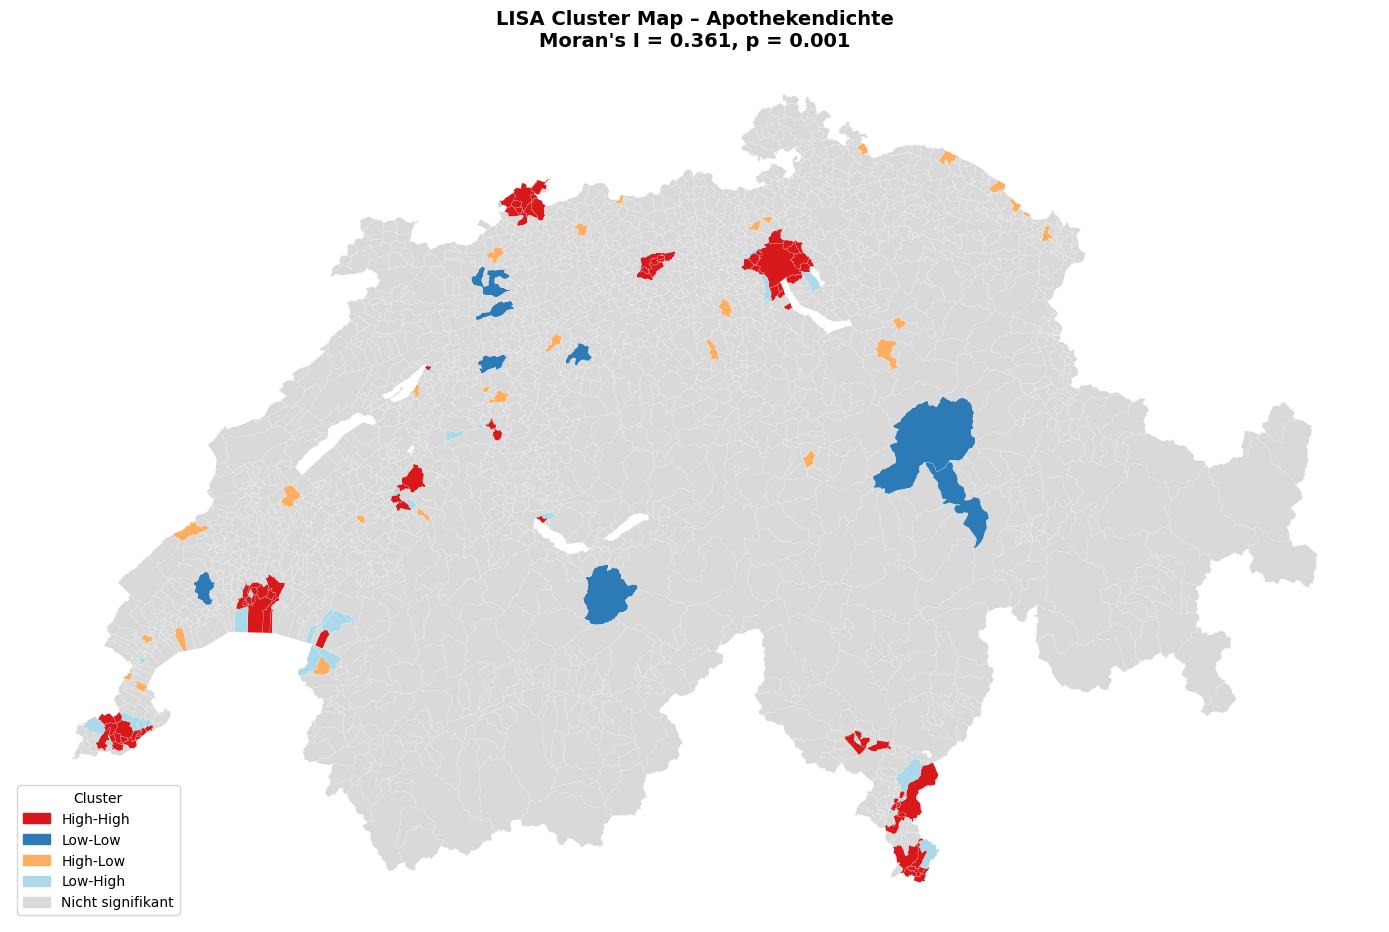

LISA Karte gespeichert: ..\outputs\maps\04_lisa_cluster.png


In [4]:
# 4) LISA Cluster Map: High-High, Low-Low, High-Low, Low-High
with warnings.catch_warnings():
    warnings.simplefilter('ignore')
    lisa = Moran_Local(y, w)

sig = lisa.p_sim < 0.05
cluster = pd.Series('Nicht signifikant', index=gdf_gem.index, dtype='object')
cluster.loc[sig & (lisa.q == 1)] = 'High-High'
cluster.loc[sig & (lisa.q == 2)] = 'Low-High'
cluster.loc[sig & (lisa.q == 3)] = 'Low-Low'
cluster.loc[sig & (lisa.q == 4)] = 'High-Low'
gdf_gem['lisa_cluster'] = cluster

print('LISA Cluster Verteilung:')
print(gdf_gem['lisa_cluster'].value_counts().to_string())

color_map = {
    'High-High':         '#d7191c',
    'Low-Low':           '#2c7bb6',
    'High-Low':          '#fdae61',
    'Low-High':          '#abd9e9',
    'Nicht signifikant': '#d9d9d9',
}

fig, ax = plt.subplots(figsize=(14, 10))
gdf_gem.plot(
    color=gdf_gem['lisa_cluster'].map(color_map),
    ax=ax, linewidth=0.1, edgecolor='white'
)
ax.set_title(
    f"LISA Cluster Map – Apothekendichte\nMoran's I = {mi.I:.3f}, p = {mi.p_sim:.3f}",
    fontsize=14, fontweight='bold'
)
ax.set_axis_off()
handles = [mpatches.Patch(color=c, label=l) for l, c in color_map.items()]
ax.legend(handles=handles, title='Cluster', loc='lower left', fontsize=10)
plt.tight_layout()
out = OUTPUTS / '04_lisa_cluster.png'
plt.savefig(out, dpi=150, bbox_inches='tight')
plt.show()
print('LISA Karte gespeichert:', out)

C:\Users\danie\AppData\Local\Temp\ipykernel_33164\3813468046.py:19: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(grouped, labels=order, patch_artist=True, showfliers=True,


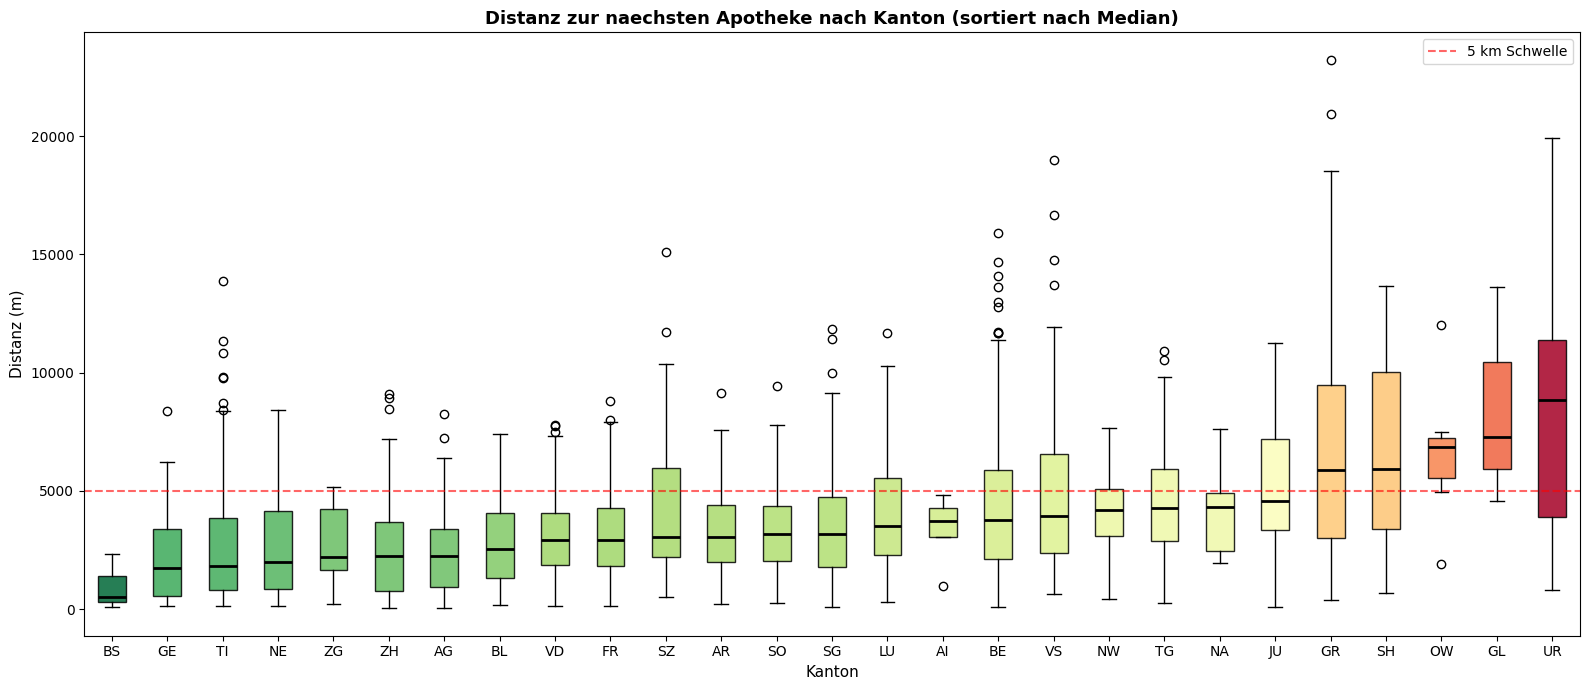

Boxplot gespeichert: ..\outputs\maps\04_boxplot_kantone.png

Best versorgte Kantone (kleinster Median):
  BS: 503 m
  GE: 1734 m
  TI: 1803 m
  NE: 1974 m
  ZG: 2196 m

Schlechtestversorgte Kantone (groesster Median):
  GR: 5872 m
  SH: 5935 m
  OW: 6874 m
  GL: 7268 m
  UR: 8829 m


In [5]:
# 5) Kantons-Vergleich Boxplot mit Kantonskuerzeln
KANTONE = {
    1:'ZH', 2:'BE', 3:'LU', 4:'UR', 5:'SZ', 6:'OW', 7:'NW', 8:'GL',
    9:'ZG', 10:'FR', 11:'SO', 12:'BS', 13:'BL', 14:'SH', 15:'AR', 16:'AI',
    17:'SG', 18:'GR', 19:'AG', 20:'TG', 21:'TI', 22:'VD', 23:'VS',
    24:'NE', 25:'GE', 26:'JU'
}

df_box = gdf_gem[['kantonsnummer','min_distanz_m']].copy()
df_box['kanton'] = df_box['kantonsnummer'].map(
    lambda x: KANTONE.get(int(float(x)), str(x)) if pd.notna(x) else 'NA'
)

order   = df_box.groupby('kanton')['min_distanz_m'].median().sort_values().index.tolist()
grouped = [df_box[df_box['kanton']==k]['min_distanz_m'].dropna().values for k in order]
medians = [np.median(g) if len(g) > 0 else 0 for g in grouped]

fig, ax = plt.subplots(figsize=(16, 7))
bp = ax.boxplot(grouped, labels=order, patch_artist=True, showfliers=True,
                medianprops=dict(color='black', linewidth=2))

norm = plt.Normalize(min(medians), max(medians))
cmap = plt.cm.RdYlGn_r
for patch, med in zip(bp['boxes'], medians):
    patch.set_facecolor(cmap(norm(med)))
    patch.set_alpha(0.85)

ax.axhline(y=5000, color='red', linestyle='--', alpha=0.6, label='5 km Schwelle')
ax.set_title('Distanz zur naechsten Apotheke nach Kanton (sortiert nach Median)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Kanton', fontsize=11)
ax.set_ylabel('Distanz (m)', fontsize=11)
ax.legend(fontsize=10)
plt.xticks(rotation=0)
plt.tight_layout()
out = OUTPUTS / '04_boxplot_kantone.png'
plt.savefig(out, dpi=150, bbox_inches='tight')
plt.show()

print('Boxplot gespeichert:', out)
print('\nBest versorgte Kantone (kleinster Median):')
for k in order[:5]:
    print(f'  {k}: {df_box[df_box["kanton"]==k]["min_distanz_m"].median():.0f} m')
print('\nSchlechtestversorgte Kantone (groesster Median):')
for k in order[-5:]:
    print(f'  {k}: {df_box[df_box["kanton"]==k]["min_distanz_m"].median():.0f} m')

Apotheken in Zuerich: 124


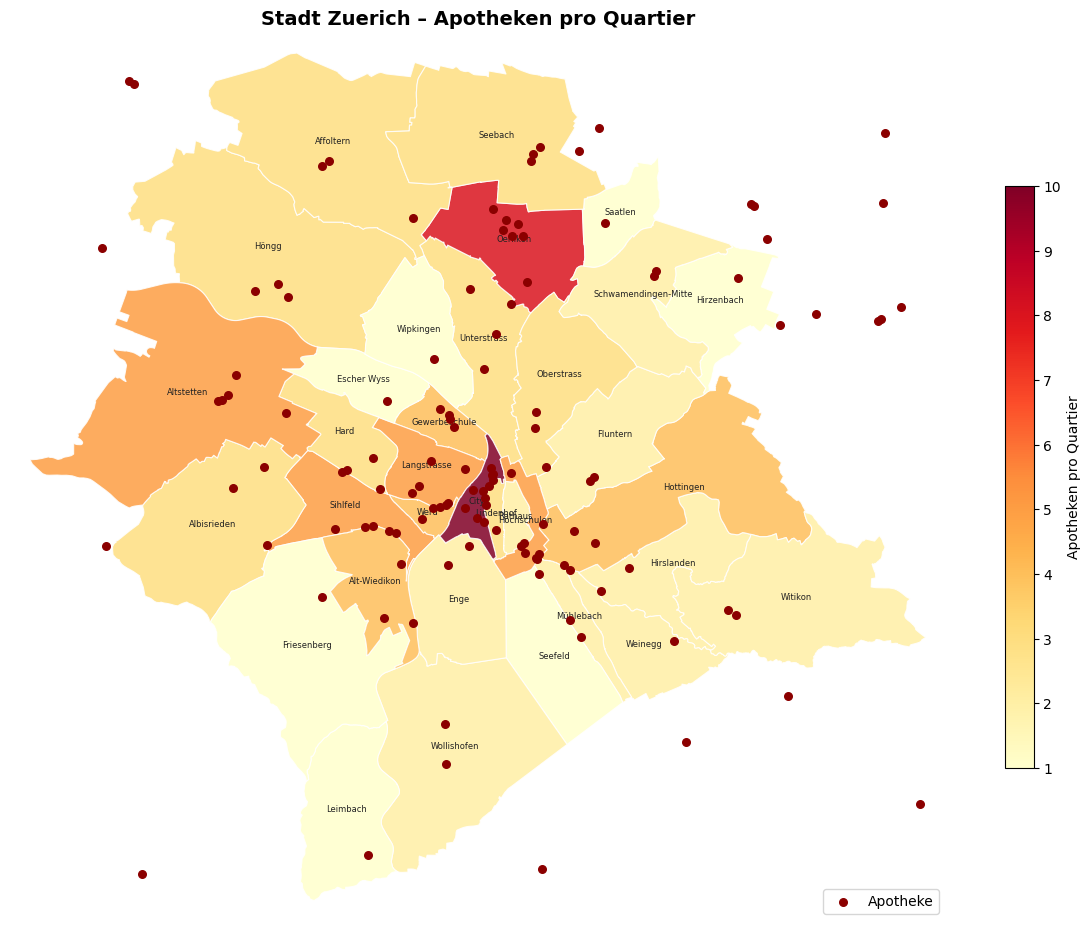

Zuerich-Karte gespeichert: ..\outputs\maps\04_zuerich_quartiere.png


In [6]:
# 6) Zuerich Karte – gezoomt auf Stadt, Quartiere nach Apothekenanzahl
xmin, ymin, xmax, ymax = gdf_quart.total_bounds
gdf_pharm_zh = gdf_pharm.cx[xmin:xmax, ymin:ymax]
print(f'Apotheken in Zuerich: {len(gdf_pharm_zh)}')

fig, ax = plt.subplots(figsize=(12, 10))
gdf_quart.plot(
    column='apotheken_anzahl', ax=ax,
    cmap='YlOrRd', legend=True,
    legend_kwds={'label': 'Apotheken pro Quartier', 'shrink': 0.6},
    edgecolor='white', linewidth=0.8, alpha=0.85
)
gdf_pharm_zh.plot(ax=ax, color='darkred', markersize=30, zorder=5, label='Apotheke')

# Quartiernamen
for _, row in gdf_quart.iterrows():
    ax.annotate(
        text=row.get('qname', ''),
        xy=(row.geometry.centroid.x, row.geometry.centroid.y),
        fontsize=6, ha='center', color='#222222'
    )

pad = 300
ax.set_xlim(xmin - pad, xmax + pad)
ax.set_ylim(ymin - pad, ymax + pad)
ax.set_title('Stadt Zuerich – Apotheken pro Quartier', fontsize=14, fontweight='bold')
ax.set_axis_off()
ax.legend(loc='lower right', fontsize=10)
plt.tight_layout()
out = OUTPUTS / '04_zuerich_quartiere.png'
plt.savefig(out, dpi=150, bbox_inches='tight')
plt.show()
print('Zuerich-Karte gespeichert:', out)